In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from src.astro_plot_utils import (
    load_table,
    extract_columns,
    hist_density,
    plot_step_hist,
    flux_to_ab_magnitude,
)

In [2]:
PATH_MOCK = "/data/astro/scratch/vdeshpan/data/FS2_mags_z.parquet"
PATH_OBS  = "/data/astro/scratch/vdeshpan/data/Q1_mags_z.parquet"

ZP_Q1 = {"g": 22.5, "r": 22.7, "i": 22.5}
ZP_FS2 = {"g": -48.6, "r": -48.6, "i": -48.6}

MOCK_COLS = {
    "g": "blanco_decam_g",
    "r": "blanco_decam_r",
    "i": "blanco_decam_i",
    "z": "true_redshift_gal",
}

OBS_COLS = {
    "g": "flux_g_ext_decam_1fwhm_aper",
    "r": "flux_r_ext_decam_1fwhm_aper",
    "i": "flux_i_ext_decam_1fwhm_aper",
    "z": "phz_median",
}

In [3]:
table_mock = load_table(PATH_MOCK)
table_obs = load_table(
    PATH_OBS,
    dropna=True,
    dropna_subset=["flux_g_ext_decam_1fwhm_aper","flux_r_ext_decam_1fwhm_aper","flux_i_ext_decam_1fwhm_aper", "phz_median"]
)

print(f"Mock loaded     : {len(table_mock):,} galaxies")
print(f"Observed loaded : {len(table_obs):,} galaxies")

Mock loaded     : 342,094,246 galaxies
Observed loaded : 79,625,141 galaxies


In [4]:
bands = ["g", "r", "i"]

mag_mock = {}
mag_obs  = {}

for b in bands:
    # Mock
    flux_m = extract_columns(table_mock, [MOCK_COLS[b]])[MOCK_COLS[b]]
    mag_mock[b] = flux_to_ab_magnitude(flux_m, zp=ZP_FS2[b])

    # Observed
    flux_o = extract_columns(table_obs, [OBS_COLS[b]])[OBS_COLS[b]]
    mag_obs[b] = flux_to_ab_magnitude(flux_o, zp=ZP_Q1[b])

    print(f"Band {b}: Mock median mag = {np.nanmedian(mag_mock[b]):.2f} | Obs median mag = {np.nanmedian(mag_obs[b]):.2f}")

Band g: Mock median mag = 25.57 | Obs median mag = 25.20
Band r: Mock median mag = 25.48 | Obs median mag = 24.93
Band i: Mock median mag = 25.40 | Obs median mag = 24.40


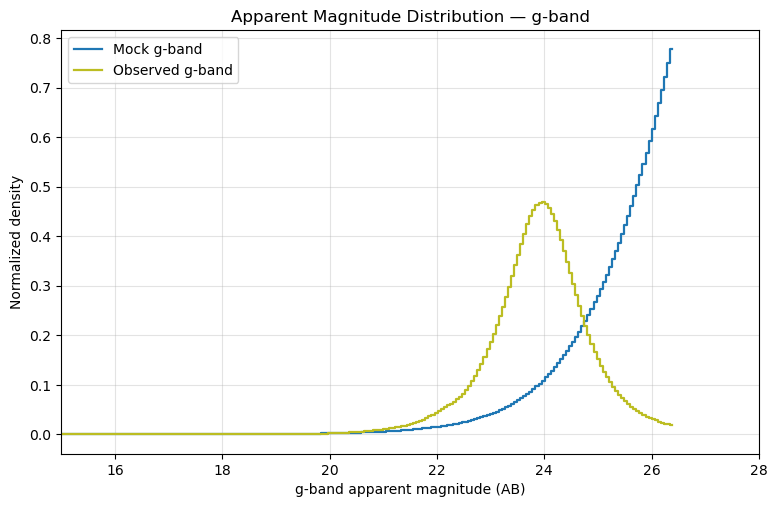

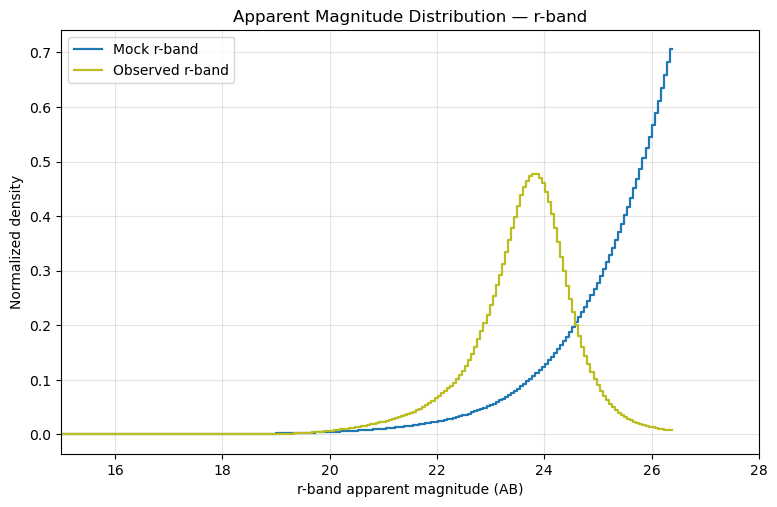

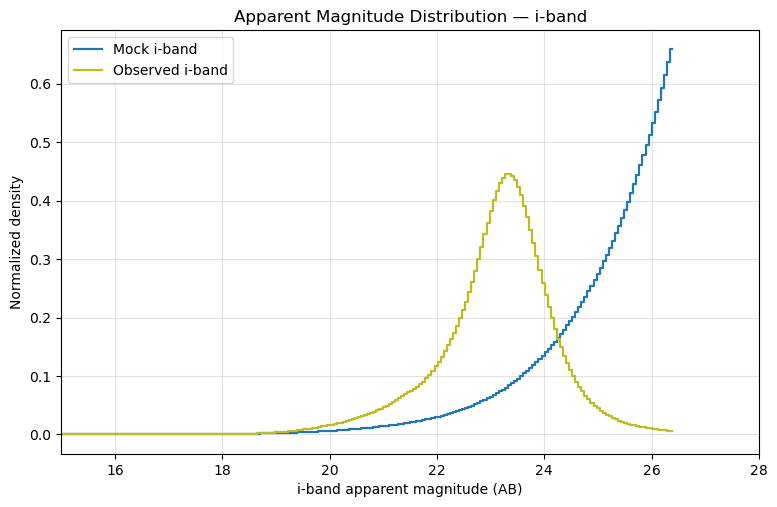

In [5]:
for b in bands:
    h_mock, c = hist_density(mag_mock[b], bins=200, clip=(15, 28))
    h_obs, _  = hist_density(mag_obs[b],  bins=200, clip=(15, 28))

    plot_step_hist(
        hists=[(h_mock, c), (h_obs, c)],
        labels=[f"Mock {b}-band", f"Observed {b}-band"],
        title=f"Apparent Magnitude Distribution — {b}-band",
        xlabel=f"{b}-band apparent magnitude (AB)",
        ylabel="Normalized density",
        xlim=(15, 28)
    )

In [14]:
# Quick completeness estimate: fraction above a given magnitude limit
g_lim = 26.5   # example reasonable cut

frac_mock_bright = np.nanmean(mag_mock["g"] < g_lim)
frac_obs_bright  = np.nanmean(mag_obs["g"]  < g_lim)

print(f"Fraction brighter than g = {g_lim}:")
print(f"  Mock: {frac_mock_bright:.1%}")
print(f"  Obs : {frac_obs_bright:.1%}")

Fraction brighter than g = 26.5:
  Mock: 30.2%
  Obs : 86.8%


In [10]:
print(f"   mock g-r median color = {np.nanmedian(mag_mock['g'] - mag_mock['r']):.3f}")
print(f"   obs  g-r median color = {np.nanmedian(mag_obs['g'] - mag_obs['r']):.3f}")

   mock g-r median color = 0.322
   obs  g-r median color = 0.349


## Notebook 04 – Selection Effects Analysis  
**Purpose**: Understand and quantify differences in selection / completeness between the observed Euclid Q1 catalog and the Flagship mock catalog **before** attempting any direct comparison of galaxy properties (especially ellipticities).

**Converts fluxes → apparent magnitudes**  
   - Observed fluxes (`flux_g_ext_decam_1fwhm_aper`, etc.) converted using DECam-like zeropoints:  
     g = 22.5, r = 22.7, i = 22.5 (approximate Legacy Survey / DECam effective values)  
   - Mock fluxes (`blanco_decam_g`, etc.) kept with the internal convention (-48.6 offset), which typically gives consistent **absolute magnitudes** or scaled apparent magnitudes in Flagship mocks.  
   → Goal: put both on a comparable apparent magnitude scale without breaking mock internal consistency.

**Quantifies completeness via cumulative fractions**  
   - Example cut: fraction of galaxies brighter than g = 26.5  
     → Mock: ~30.2%  
     → Observed: ~86.8%  
   - Shows the observed catalog is significantly deeper in g-band (includes many more faint objects).

6. **Checks color consistency**  
   - Median g–r color:  
     Mock: 0.322  
     Observed: 0.349  
     (Δ ≈ 0.03 mag — very good agreement)  
   → Demonstrates that relative calibration (colors) between mock and observed is reliable → safe to use color bins later for K-corrections or other matching.

### Key findings & implications

- **Observed data is deeper** than the mock (especially in bluer bands).  
  At g = 26.5, ~87% of observed galaxies pass vs only ~30% in mock → strong selection effect.

- **Colors agree well** (g–r difference only ~0.03 mag) → relative photometry / color calibration is consistent → we can trust color-based binning in future steps.

- **Direct comparison of ellipticities (e1, e2) would be biased right now**  
  because the samples probe different luminosity / redshift regimes.  
  → Must apply a **common apparent magnitude cut** first (e.g. g < 26.0 **and** i < 25.5, or whichever limit makes completeness similar in both catalogs).

### Next steps (planned notebooks)

- **05**: Apply common magnitude cut(s) → re-check distributions & completeness after cut  
- **06**: Bin in redshift + color → compute & assign K-corrections statistically (PDF/CDF method)  
- **07+**: Compute absolute magnitudes → bin in (z, M_abs) → compare ellipticities apples-to-apples

**Last updated**: March 2026  
This notebook is part of the validation suite in the repository `pic-internship-euclid-hod-ellipticities`.

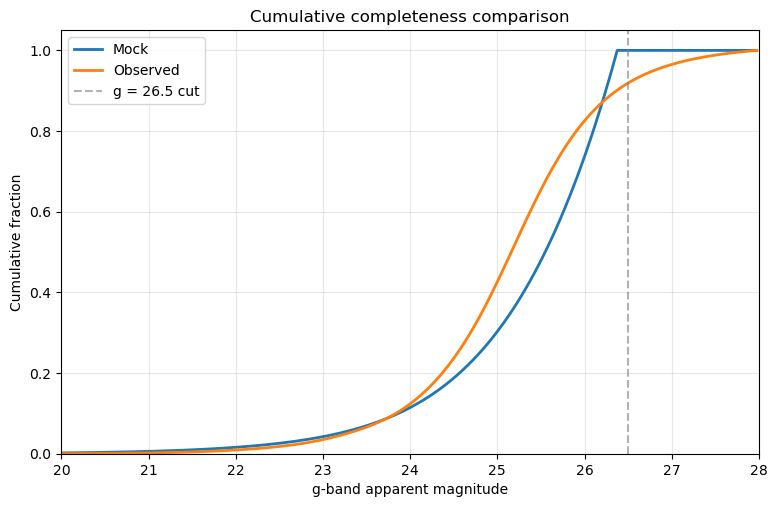

In [12]:
# Cell: Cumulative magnitude distribution comparison
g_bins = np.linspace(18, 28, 201)
g_centers = 0.5 * (g_bins[:-1] + g_bins[1:])

cum_mock, _ = np.histogram(mag_mock['g'], bins=g_bins, density=False)
cum_obs,  _ = np.histogram(mag_obs['g'],  bins=g_bins, density=False)

cum_mock = np.cumsum(cum_mock) / cum_mock.sum()
cum_obs  = np.cumsum(cum_obs)  / cum_obs.sum()

plt.figure(figsize=(9, 5.5))
plt.plot(g_centers, cum_mock, label='Mock', lw=2)
plt.plot(g_centers, cum_obs,  label='Observed', lw=2)
plt.axvline(26.5, color='gray', ls='--', alpha=0.6, label='g = 26.5 cut')
plt.xlabel('g-band apparent magnitude')
plt.ylabel('Cumulative fraction')
plt.title('Cumulative completeness comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(20, 28)
plt.ylim(0, 1.05)
plt.show()